# First Approach

In this notebook I try to 
- recreate the VLT PSF, 
- add phase errors to see appear speckles, 
- add a companion object offcentred, 
- and add a coronograph.

In [80]:
from hcipy import *
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import os

# Simulate VLT telescope pupil

We will model here the VLT pupil, of 8m in diameter (the primary mirror is 8.2m but the actual pupil is restricted by M2 to 8m, there is an extra margin used for choping in the infrared).

We represent the pupil by a grid of 240px. This is the sampling used by the SH WFS of SPHERE, which is an EMCCD of 240x240px (6px per subapertures, with 40 subapertures on one diameter). 
To avoid some numerical problems at the edges, we oversize the pupil grid by a factor 16 / 15, e.g. the grid is represented by a grid of 240 * 16 / 15 = 256 px.

The factor 4 indicates that each pixel will be evaluated with 4x supersampling, effectively averaging 4x4=16 subpixels for each pixel.

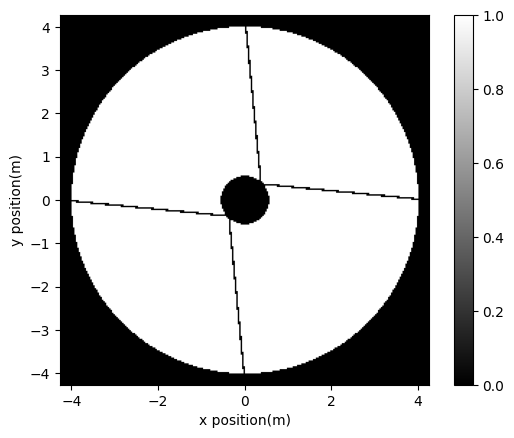

In [40]:
pupil_diameter = 8 # m
central_obscuration = 1.2 # meter
central_obscuration_ratio = central_obscuration / pupil_diameter
spider_width = 0.05 # meter
oversizing_factor = 16 / 15
#effective_focal_length = 71.5 # m


num_pupil_pixels = 240 * oversizing_factor
pupil_grid_diameter = pupil_diameter * oversizing_factor

pupil_grid = make_pupil_grid(num_pupil_pixels, pupil_grid_diameter)

telescope_pupil_generator = make_vlt_aperture() 


telescope_pupil = telescope_pupil_generator(pupil_grid)


im = imshow_field(telescope_pupil, cmap='gray')
plt.colorbar()
plt.xlabel('x position(m)')
plt.ylabel('y position(m)')
plt.show()

## Incoming wavefront and PSF generation

Let's assume we work with monochromatic light at 700nm for wavefront sensing and in the K band at 2.2 micron for the scientific channel

Let visualize the corresponding diffraction pattern. To do so, we need to propagate the wavefront from the pupil to a focal plane. We assume here a perfect lens (see :class:`FraunhoferPropagator` for details on the model).

We also need to sample the electric field on a focal plane. We use here 4 pixels per resolution elements(q) and set the field of view to 30 lambda/D (num_airy) in radius at the science wavelength.

To convert a Wavefront into an observed image, one can simply use the Wavefront.power attribute, which is the Wavefront.intensity multiplied by the weight at each pixel.


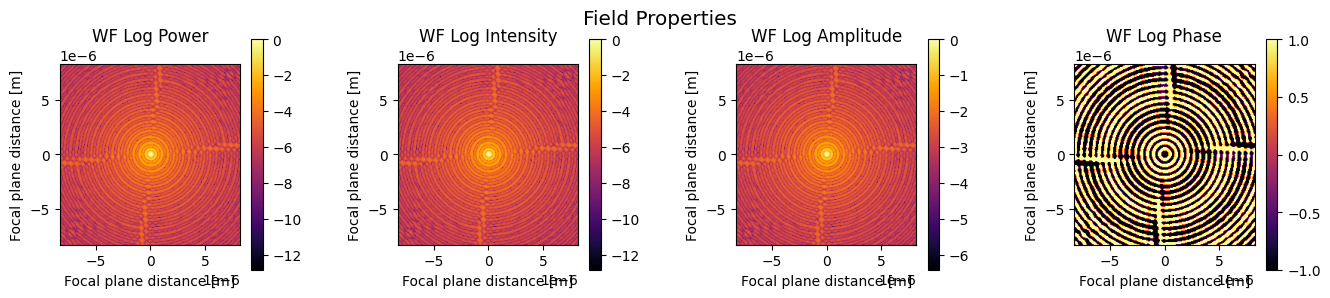

In [41]:
q = 4 #number of pixels per diffraction width, 
num_airy = 30 #half size (ie. radius) of the image in the number of diffraction widths.


wavelength_wfs = 0.7e-6
wavelength_sci = 2.2e-6
spatial_resolution = wavelength_sci / pupil_diameter


wavefront = Wavefront(telescope_pupil, wavelength_sci)
wavefront.total_power = 1

focal_grid = make_focal_grid(q=q, num_airy=num_airy, spatial_resolution=spatial_resolution)
propagator = FraunhoferPropagator(pupil_grid, focal_grid)

unaberrated_PSF_ = propagator.forward(wavefront)
unaberrated_PSF = unaberrated_PSF_.power

plt.figure(figsize=(16,3))
plt.subplot(1,4,1)
plt.title('WF Log Power')
imshow_field(np.log10(unaberrated_PSF_.power / unaberrated_PSF_.power.max()), cmap='inferno')
plt.xlabel('Focal plane distance [m]')
plt.ylabel('Focal plane distance [m]')
plt.colorbar()

plt.subplot(1,4,2)
plt.title('WF Log Intensity')
imshow_field(np.log10(unaberrated_PSF_.intensity / unaberrated_PSF_.intensity.max()), cmap='inferno')
plt.xlabel('Focal plane distance [m]')
plt.ylabel('Focal plane distance [m]')
plt.colorbar()

plt.subplot(1,4,3)
plt.title('WF Log Amplitude')
imshow_field(np.log10(unaberrated_PSF_.amplitude / unaberrated_PSF_.amplitude.max()), cmap='inferno')
plt.xlabel('Focal plane distance [m]')
plt.ylabel('Focal plane distance [m]')
plt.colorbar()

plt.subplot(1,4,4)
plt.title('WF Log Phase')
imshow_field((unaberrated_PSF_.phase / unaberrated_PSF_.phase.max()), cmap='inferno')
plt.xlabel('Focal plane distance [m]')
plt.ylabel('Focal plane distance [m]')
plt.colorbar()

plt.suptitle(f'Field Properties', fontsize='x-large')
plt.subplots_adjust(wspace = 0.5)
plt.show()

# Add aberrations

Try atm and quasi static specle generation

## Atmospheric

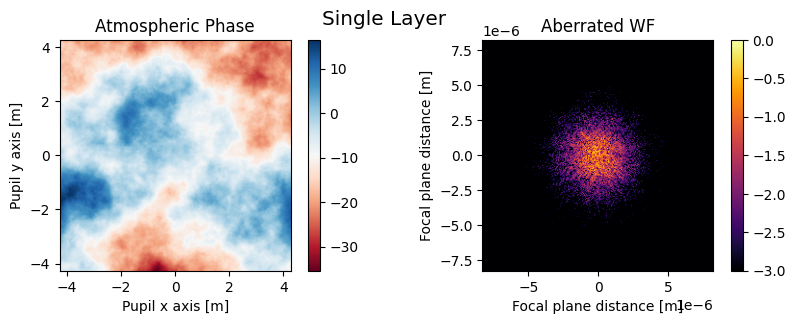

In [42]:
fried_parameter = 0.2 # meter  
outer_scale = 20 # meter  
velocity = 10 # meter/sec  
wavelength_atm = 500e-9
Cn_squared = Cn_squared_from_fried_parameter(fried_parameter, wavelength_atm) 
 
layer = InfiniteAtmosphericLayer(pupil_grid, Cn_squared, outer_scale, velocity) #infinite phase-screen extrusion method 


#check aberrated 500nm wf
plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
plt.title('Atmospheric Phase')
imshow_field(layer.phase_for(wavelength_atm), cmap='RdBu')
plt.colorbar()
plt.xlabel('Pupil x axis [m]')
plt.ylabel('Pupil y axis [m]')


plt.subplot(1,2,2)
plt.title('Aberrated WF')
aberrated_wf = Wavefront(telescope_pupil, wavelength_atm)  
img = propagator(layer(aberrated_wf))  
imshow_field(np.log10(img.intensity / img.intensity.max()), cmap = 'inferno', vmin=-3)
plt.colorbar()
plt.xlabel('Focal plane distance [m]')
plt.ylabel('Focal plane distance [m]')
plt.suptitle(f'Single Layer', fontsize='x-large')
plt.show()



Multiple layers

In [43]:
layers = []
fried_parameter = np.linspace(0.2, 0.6, 5) # meter  
outer_scale = np.linspace(15, 25, 5) # meter  
velocity = np.linspace(2, 15, 5) # meter/sec  

for (fr, os, vel) in zip(fried_parameter, outer_scale, velocity):
    Cn = Cn_squared_from_fried_parameter(fr, wavelength_atm) 
    lay = InfiniteAtmosphericLayer(pupil_grid, Cn, os, vel) #infinite phase-screen extrusion method 
    layers.append(lay)
atmos = MultiLayerAtmosphere(layers, scintillation=True) 
layers

/var/folders/r5/j23mvkb93rbfkzn801cj78lc000_7s/T/ipykernel_43610/624583684.py:5: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  amt = np.sum(x.phase_for(wavelength_atm) for x in np.array(layers))


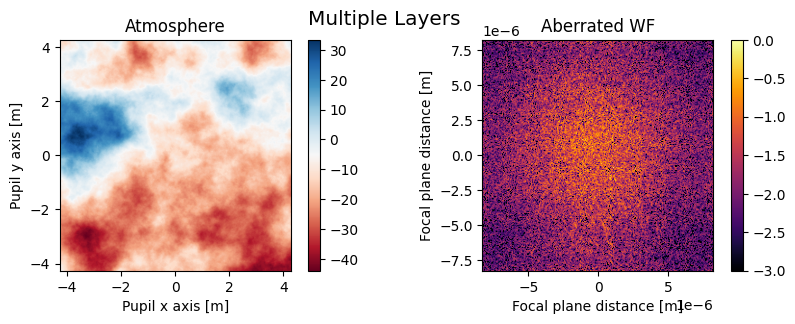

In [44]:
# Use super-Gaussian to avoid edge effects  
#p = np.exp(-(pupil_grid.as_('polar').r/0.68)**20) 
#smooth_pupil = Field(p, pupil_grid)
wf_atmo_aberrated = atmos(Wavefront(telescope_pupil, wavelength_atm)) 
amt = np.sum(x.phase_for(wavelength_atm) for x in np.array(layers))

#check aberrated 500nm wf
plt.figure(figsize=(10,3))


plt.subplot(1,2,1)
plt.title('Atmosphere')
imshow_field(amt, cmap='RdBu')
plt.colorbar()
plt.xlabel('Pupil x axis [m]')
plt.ylabel('Pupil y axis [m]')

plt.subplot(1,2,2)
plt.title('Aberrated WF')
img = propagator(atmos(wf_atmo_aberrated))  
imshow_field(np.log10(img.intensity / img.intensity.max()), cmap = 'inferno', vmin=-3)
plt.colorbar()
plt.xlabel('Focal plane distance [m]')
plt.ylabel('Focal plane distance [m]')
plt.suptitle(f'Multiple Layers', fontsize='x-large')
plt.show()

## Instrumental Aberrations

In [49]:
SurfaceApodizer?
make_power_law_error?
ncpas = make_power_law_error(pupil_grid, 1e-6, pupil_diameter, -2.5).squeeze()
ncpas[telescope_pupil.astype(bool)] -= np.mean(ncpas[telescope_pupil.astype(bool)])
ncpa_surface = SurfaceApodizer(.5*ncpas, refractive_index = -1)

/Users/nbensous/hcipy/hcipy/optics/aberration.py:38: RuntimeWarning: divide by zero encountered in power
  res = Field(grid.as_('polar').r**exponent, grid)


Signature:
make_power_law_error(
    pupil_grid,
    ptv,
    diameter,
    exponent=-2.5,
    aperture=None,
    remove_modes=None,
)
Docstring:
Create an error surface from a power-law power spectral density.

Parameters
----------
pupil_grid : Grid
    The grid on which to calculate the error.
ptv : scalar
    The peak-to-valley of the wavefront aberration in meters.
diameter : scalar
    The diameter over which the ptv is calculated.
exponent : scalar
    The exponent of the power law.
aperture : Field
    The mask over which to calculate the ptv. A circular aperture with diameter
    `diameter` is used if this is not given.
remove_modes : ModeBasis
    The modes which to remove from the surface aberration. The peak-to-valley
    is enforced before these modes are removed. This allows for correctting surface
    errors with optic alignment.

Returns
-------
Field
    The surface error calculated on `pupil_grid`.
File:      ~/hcipy/hcipy/optics/aberration.py
Type:      function

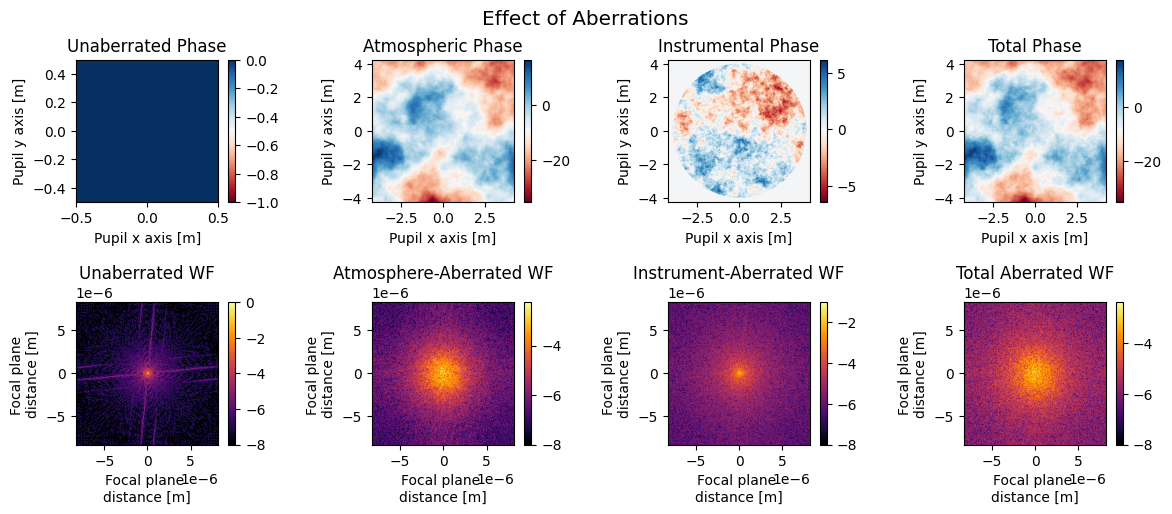

In [48]:
#check aberrated 500nm wf
aberrated_wf = Wavefront(telescope_pupil, wavelength_atm)  
no_img = propagator((aberrated_wf)).intensity
img_atm = propagator(layer(aberrated_wf)).intensity
img_ins = propagator(ncpa_surface(aberrated_wf)).intensity
img = propagator(ncpa_surface(layer(aberrated_wf))).intensity
total_ab = layer.phase_for(wavelength_atm) + ncpa_surface.phase(wavelength_atm)


titles = ['Atmospheric Phase', 'Instrumental Phase', 'Total Phase', 'Unaberrated WF', 'Atmosphere-Aberrated WF', 'Instrument-Aberrated WF', 'Total Aberrated WF']
figs = [layer.phase_for(wavelength_atm), ncpa_surface.phase(wavelength_atm), total_ab, no_img, img_atm, img_ins, img]

plt.figure(figsize=(14,5))
plt.subplot(2,4,1)
imshow_field(Field(0, make_uniform_grid((1,1),(1,1))), cmap='RdBu', vmax = 0, vmin = -1)
plt.colorbar()
plt.xlabel('Pupil x axis [m]')
plt.ylabel('Pupil y axis [m]')
plt.title('Unaberrated Phase')


for i in range(2,9):
    plt.subplot(2,4,i)
    plt.title(titles[i-2])
    if i < 5:
        imshow_field((figs[i-2]), cmap='RdBu')
        plt.colorbar()
        plt.xlabel('Pupil x axis [m]')
        plt.ylabel('Pupil y axis [m]')
    else:
        imshow_field(np.log10(figs[i-2]/no_img.max()), cmap = 'inferno', vmin = -8)
        plt.colorbar()
        plt.xlabel('Focal plane \ndistance [m]')
        plt.ylabel('Focal plane \ndistance [m]')

plt.suptitle('Effect of Aberrations', fontsize='x-large')
plt.subplots_adjust(hspace=0.7, wspace = 0.5)
plt.show()

# Add a compagnon

In [ ]:
contrast = 3e-3
angular_separation = 1 # lambda / D
num_photons_star = 1e9


def science_image_generation(telescope_pupil, pupil_grid, angular_separation, wavelength_sci, num_photons_star, contrast):
    wf_star = Wavefront(telescope_pupil, wavelength_sci)
    wf_star.total_power = num_photons_star
    e_planet = telescope_pupil * np.exp(2j * np.pi * pupil_grid.x * angular_separation)
    wf_planet = Wavefront(e_planet, wavelength_sci)
    wf_planet.total_power = num_photons_star * contrast

    # Calculate science image for the star and planet
    science_image = propagator(wf_star).power
    science_image += propagator(wf_planet).power

    # Simulate photon noise
    science_image = large_poisson(science_image)
    return science_image

science_image = science_image_generation(telescope_pupil, pupil_grid, angular_separation, wavelength_sci, num_photons_star, contrast)

imshow_field(np.log10(science_image / science_image.max() + 1e-20), cmap='inferno', vmin=-5, vmax=0)
plt.xlabel('Focal plane distance [m]')
plt.ylabel('Focal plane distance [m]')
plt.title('Ideal Star + Planet')
plt.colorbar()
plt.show()

check the intensty of the wavefront to see hoz resolved the objects are

In [ ]:
def intensity_profile_generation(science_image):
    psf = science_image.grid
    psf_shape = psf.shape
    slicefoc = science_image[120*240:121*240]
    slicefoc_normalised = slicefoc / slicefoc.max()
    return slicefoc_normalised

slicefoc_normalised = intensity_profile_generation(science_image)

plt.plot(np.linspace(-pupil_grid_diameter, pupil_grid_diameter, 240), slicefoc_normalised)
plt.xlabel('Focal plane distance [$\lambda/D$]')
plt.ylabel('Normalised intensity [I]')
plt.yscale('log')
plt.title('System intensity profile in diffraction units')
plt.show()


try to make an animation in terms of angular separation

In [ ]:
angular_separations = np.arange(0, 5, 0.5)

# Starting the animation object to write to an mp4 file.
anim = FFMpegWriter('resolution.mp4', framerate=3)


for sep in angular_separations:
    f, (a0, a1) = plt.subplots(1, 2, figsize = (10,4), gridspec_kw={'width_ratios': [1, 3], 'height_ratios': [1]})
    plt.subplot(1, 2, 1)
    science_image = science_image_generation(telescope_pupil, pupil_grid, sep, wavelength_sci, num_photons_star, contrast)

    imshow_field(np.log10(science_image / science_image.max() + 1e-20), cmap='inferno', vmin=-5, vmax=0)
    plt.xlabel('Focal plane distance [m]')
    plt.ylabel('Focal plane distance [m]')
    plt.colorbar(fraction = 0.04)

    plt.subplot(1, 2, 2)
    slicefoc_normalised = intensity_profile_generation(science_image)

    plt.plot(np.linspace(-pupil_grid_diameter, pupil_grid_diameter, 240), slicefoc_normalised)
    plt.xlabel('Focal plane distance [$\lambda/D$]')
    plt.ylabel('Normalised intensity [I]')
    plt.yscale('log')
    plt.title('System intensity profile in diffraction units')
    

    plt.suptitle(f'Angualr Separation {sep} lambda / D', fontsize='x-large')
    plt.subplots_adjust(wspace = 0.4, top = 0.8)

    # Adding the frame to the mp4 file and closing the created figure.
    anim.add_frame()
    plt.close()

anim.close()

anim



In [ ]:
os.remove('resolution.mp4')

# Add coronograph
Try:
- Vortex 
- Vector Vortex (help from the online course too https://supaerotlse-my.sharepoint.com/personal/noah_bensoussan_isae-supaero_fr/_layouts/15/Doc.aspx?sourcedoc={41ffd4f4-3a59-4ef4-a505-7e18582fe4c6}&action=edit&wd=target%28Resoources.one%7Cf977a600-f87c-4132-8e24-3f07d62af961%2FHCIPy%7C5954efaf-cc92-475f-b078-da855c00e596%2F%29&wdorigin=NavigationUrl)

https://docs.hcipy.org/dev/modules/coronagraphy.html

## Vortex Coronograph

In [ ]:
charge = 4
#lyot_mask_diameter = 6 #smaller than pupil
# Create aperture and dark zone
#aperture = Field(np.exp(-(pupil_grid.as_('polar').r / (0.5 * pupil_diameter))**30), pupil_grid)
#Lyot_mask = Field(np.exp(-(pupil_grid.as_('polar').r / (0.5 * lyot_mask_diameter))**30), pupil_grid)
#lyot_stop = Apodizer(Lyot_mask)

# lyot stop on smaller aperture
pupil_grid_small = make_pupil_grid(num_pupil_pixels, pupil_diameter)
telescope_pupil_small = telescope_pupil_generator(pupil_grid_small)
lyot_stop = Apodizer(telescope_pupil_small)


vortex = VortexCoronagraph(pupil_grid, charge)


plt.figure(figsize=(13,4))
plt.subplot(1,3,1)
plt.title('Telescope Pupil')
imshow_field(telescope_pupil, cmap = 'gray')
plt.xlabel('Focal plane distance [m]')
plt.ylabel('Focal plane distance [m]')
plt.colorbar()

plt.subplot(1,3,2)
plt.title('Focal-plane mask')
imshow_field(np.exp(1j * charge * focal_grid.as_('polar').theta), focal_grid, vmin =0)
plt.xlabel('Focal plane distance [m]')
plt.ylabel('Focal plane distance [m]')
plt.colorbar()

plt.subplot(1,3,3)
plt.title('Lyot-stop')
imshow_field(telescope_pupil_small, cmap = 'gray')
plt.xlabel('Focal plane distance [m]')
plt.ylabel('Focal plane distance [m]')
plt.colorbar()

plt.subplots_adjust(wspace = 0.3)
plt.suptitle('Charge 4 Vortex Coronograph', fontsize='x-large')
plt.show()

In [ ]:
# propagate light through coro onto the Lyot plane 
wf_star = Wavefront(telescope_pupil, wavelength_sci)
wf_star.total_power = num_photons_star
e_planet = telescope_pupil * np.exp(2j * np.pi * pupil_grid.x * angular_separation)
wf_planet = Wavefront(e_planet, wavelength_sci)
wf_planet.total_power = num_photons_star * contrast

lyot_star = vortex(wf_star)
lyot_planet = vortex(wf_planet)

lyot_plane = lyot_star.power + lyot_planet.power

# Simulate photon noise
lyot_plane_sn = large_poisson(lyot_plane)


#Propagate 
Img_coro_star = propagator(lyot_stop(lyot_star))
Img_coro_planet = propagator(lyot_stop(lyot_planet))

Img_coro = Img_coro_star.power + Img_coro_planet.power
# Simulate photon noise
Img_coro_sn = large_poisson(Img_coro)

fig1 = [science_image, lyot_star.power, lyot_planet.power, lyot_plane]
fig2 = [science_image, Img_coro_star.power, Img_coro_planet.power, Img_coro_sn]
labels = ['Log Ideal Star + Planet', 'Log Coro + Star', 'Log Coro + Panet', 'Log Coro + Star + Planet \n+ Shot Noise']

for i in range(8):
    if i%4 == 0:
        plt.figure(figsize=(19,4))

    if i < 4:
        fig = fig1
        title = 'Propagation onto the Lyot Plane'
    else:
        fig = fig2
        title = 'Propagation at the Science Camera'

    plt.subplot(1,4,i%4 +1)
    
    imshow_field(np.log10(fig[i%4] / science_image.max() + 1e-20), cmap='inferno', vmin=-5, vmax=0)
    plt.xlabel('Focal plane distance [m]')
    plt.ylabel('Focal plane distance [m]')
    plt.title(labels[i%4])
    plt.colorbar()

    if i%4 == 3:
        plt.suptitle(title, fontsize='x-large')
        plt.show()



## Vector Vortex Coronograph

In [ ]:
VecVortex = VectorVortexCoronagraph(charge, telescope_pupil_small)

lyot_star = VecVortex(wf_star)
lyot_planet = VecVortex(wf_planet)

lyot_plane = lyot_star.power + lyot_planet.power

# Simulate photon noise
lyot_plane_sn = large_poisson(lyot_plane)


#Propagate 
Img_coro_star = propagator(lyot_stop(lyot_star))
Img_coro_planet = propagator(lyot_stop(lyot_planet))

Img_coro = Img_coro_star.power + Img_coro_planet.power
# Simulate photon noise
Img_coro_sn = large_poisson(Img_coro)

fig1 = [science_image, lyot_star.power, lyot_planet.power, lyot_plane]
fig2 = [science_image, Img_coro_star.power, Img_coro_planet.power, Img_coro_sn]
labels = ['Log Ideal Star + Planet', 'Log Coro + Star', 'Log Coro + Panet', 'Log Coro + Star + Planet \n+ Shot Noise']

for i in range(8):
    if i%4 == 0:
        plt.figure(figsize=(19,4))

    if i < 4:
        fig = fig1
        title = 'Propagation onto the Lyot Plane'
    else:
        fig = fig2
        title = 'Propagation at the Science Camera'

    plt.subplot(1,4,i%4 +1)
    
    imshow_field(np.log10(fig[i%4] / science_image.max() + 1e-20), cmap='inferno', vmin=-5, vmax=0)
    plt.xlabel('Focal plane distance [m]')
    plt.ylabel('Focal plane distance [m]')
    plt.title(labels[i%4])
    plt.colorbar()

    if i%4 == 3:
        plt.suptitle(title, fontsize='x-large')
        plt.show()


# Instrument-Aberrated System with a Coronograph

In [1]:
from hcipy import *
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import os

In [56]:
def generate_focal_plane(wavelength_sci, pupil_diameter, num_pupil_pixels, pupil_grid_diameter, q, num_airy):

    spatial_resolution = wavelength_sci / pupil_diameter 
    pupil_grid = make_pupil_grid(num_pupil_pixels, pupil_grid_diameter)
    telescope_pupil_generator = make_vlt_aperture() 
    telescope_pupil = telescope_pupil_generator(pupil_grid)
    focal_grid = make_focal_grid(q=q, num_airy=num_airy, spatial_resolution=spatial_resolution)
    propagator = FraunhoferPropagator(pupil_grid, focal_grid)
    return telescope_pupil, pupil_grid, propagator

def generated_aberrated_frames(num_pupil_pixels, pupil_diameter, pupil_grid_diameter, q, num_airy, 
                               wavelength_sci, contrast, angular_separation, num_photons_star, 
                               ptv = None,
                               charge = None,
                               fried_parameter = None, outer_scale = None, velocity = None,
                               shot_noise = False):

    # telescope pupil and focal plane
    telescope_pupil, pupil_grid, propagator = generate_focal_plane(wavelength_sci, pupil_diameter, num_pupil_pixels, pupil_grid_diameter, q, num_airy)

    # wavefronts
    wf_star = Wavefront(telescope_pupil, wavelength_sci)
    wf_star.total_power = num_photons_star
    e_planet = telescope_pupil * np.exp(2j * np.pi * pupil_grid.x * angular_separation)
    wf_planet = Wavefront(e_planet, wavelength_sci)
    wf_planet.total_power = num_photons_star * contrast

    if fried_parameter:
        # atmosphere
        Cn_squared = Cn_squared_from_fried_parameter(fried_parameter, wavelength_sci)  
        layer = InfiniteAtmosphericLayer(pupil_grid, Cn_squared, outer_scale, velocity) #infinite phase-screen extrusion method 
        wf_star = layer(wf_star)
        wf_planet = layer(wf_planet)

    # lyot stop pupil (a little smaller)
    telescope_pupil_small, _, _ = generate_focal_plane(wavelength_sci, pupil_diameter, num_pupil_pixels, pupil_diameter, q, num_airy)
    lyot_stop = Apodizer(telescope_pupil_small)
    
    if charge:
        # Vector Vortex coronograph
        VecVortex = VectorVortexCoronagraph(charge, telescope_pupil_small)
        wf_star = lyot_stop(VecVortex((wf_star)))
        wf_planet = lyot_stop(VecVortex((wf_planet)))

    if ptv:
        # ncpa
        ncpas = make_power_law_error(pupil_grid, ptv, pupil_grid_diameter, -2.5).squeeze()
        ncpas[telescope_pupil.astype(bool)] -= np.mean(ncpas[telescope_pupil.astype(bool)])
        ncpa_surface = SurfaceApodizer(.5*ncpas, refractive_index = -1)
        wf_star = ncpa_surface((wf_star))
        wf_planet = ncpa_surface((wf_planet))

    # propagation (WF -> atm -> coronograph -> ncpa)
    star = propagator.forward(((((wf_star)))))
    planet = propagator.forward(((((wf_planet)))))
    science_img = star.intensity + planet.intensity

    if shot_noise == True:
        # Simulate photon noise
        science_img = large_poisson(science_img)

    return science_img

In [57]:
#all the constants:
oversizing_factor = 16 / 15
num_pupil_pixels = 240 * oversizing_factor
pupil_diameter = 8 # m
pupil_grid_diameter = pupil_diameter * oversizing_factor

q = 4 #number of pixels per diffraction width, 
num_airy = 30 #half size (ie. radius) of the image in the number of diffraction widths.

wavelength_sci = 2.2e-6

fried_parameter = 0.5 # meter  
outer_scale = 20 # meter  
velocity = 10 # meter/sec  

contrast = 3e-4
angular_separation = 1 # lambda / D
num_photons_star = 1e9

charge = 4

ptv = 1e-6

Science_img = generated_aberrated_frames(num_pupil_pixels, pupil_diameter, pupil_grid_diameter, q, num_airy, 
                                         wavelength_sci, contrast, angular_separation, num_photons_star)

Science_img_sn = generated_aberrated_frames(num_pupil_pixels, pupil_diameter, pupil_grid_diameter, q, num_airy, 
                               wavelength_sci, contrast, angular_separation, num_photons_star, shot_noise=True)

Science_img_coro = generated_aberrated_frames(num_pupil_pixels, pupil_diameter, pupil_grid_diameter, q, num_airy, 
                               wavelength_sci, contrast, angular_separation, num_photons_star, charge = charge, shot_noise=True)

Science_img_ncpa_coro = generated_aberrated_frames(num_pupil_pixels, pupil_diameter, pupil_grid_diameter, q, num_airy, 
                               wavelength_sci, contrast, angular_separation, num_photons_star, ptv= ptv, charge = charge, shot_noise=True)

Science_img_with_atmo = generated_aberrated_frames(num_pupil_pixels, pupil_diameter, pupil_grid_diameter, q, num_airy, 
                                                   wavelength_sci, contrast, angular_separation, num_photons_star, ptv, charge, fried_parameter, outer_scale, velocity, shot_noise=True)

# telescope pupil and focal plane
telescope_pupil, pupil_grid, propagator = generate_focal_plane(wavelength_sci, pupil_diameter, num_pupil_pixels, pupil_grid_diameter, q, num_airy)

e_planet = telescope_pupil * np.exp(2j * np.pi * pupil_grid.x * angular_separation)
wf_planet = Wavefront(e_planet, wavelength_sci)
wf_planet.total_power = num_photons_star * contrast

planet = propagator.forward(((((wf_planet))))).intensity



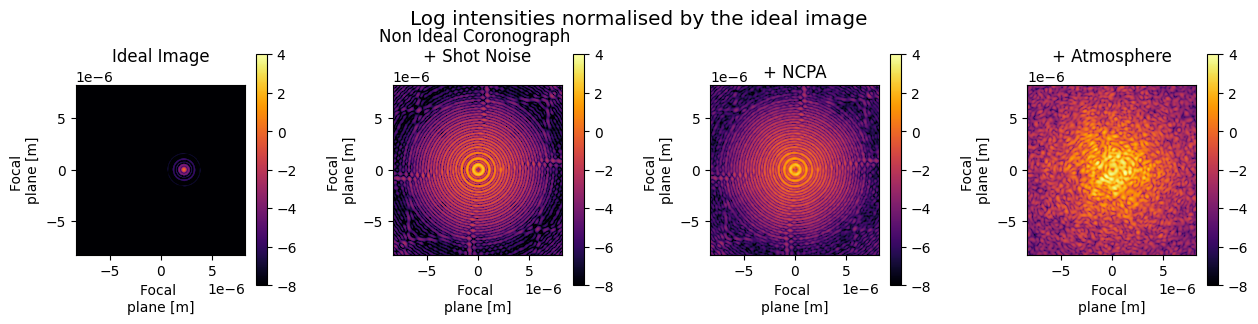

In [78]:
figs = [ planet, Science_img_coro, Science_img_ncpa_coro, Science_img_with_atmo]
titles = ['Ideal Image', 'Non Ideal Coronograph \n+ Shot Noise', '+ NCPA', '+ Atmosphere']

plt.figure(figsize=(15,3))
for i in range(np.size(titles)):
    plt.subplot(1, int(np.size(titles)), i+1)
    imshow_field(np.log(figs[i]/planet.max()), cmap='inferno', vmax = 4, vmin =-8)
    plt.colorbar()
    plt.xlabel('Focal \nplane [m]')
    plt.ylabel('Focal \nplane [m]')
    plt.title(titles[i])

plt.suptitle(f'Log intensities normalised by the ideal image', fontsize='x-large', va = 'baseline')
    
plt.subplots_adjust(wspace = 0.5)
plt.show()

In [68]:

ptv = np.linspace(1e-15,1e-5,25)
#RefractiveIndex = -1 * RefractiveIndex

# Starting the animation object to write to an mp4 file.
anim = FFMpegWriter('refractiveindex.mp4', framerate=5)

imshow_field(np.log10(Science_img_coro), cmap='inferno')
plt.colorbar()
plt.xlabel('Focal plane distance [m]')
plt.ylabel('Focal plane distance [m]')
plt.title(f'No Instrumental Aberration', fontsize='x-large')

# Adding the frame to the mp4 file and closing the created figure.
anim.add_frame()
plt.close()

for val in ptv:
    img = generated_aberrated_frames(num_pupil_pixels, pupil_diameter, pupil_grid_diameter, q, num_airy, 
                                     wavelength_sci, contrast, angular_separation, num_photons_star, 
                                     ptv= val, charge = charge, shot_noise=True)

    imshow_field(np.log10(img), cmap='inferno')
    plt.colorbar()
    plt.xlabel('Focal plane distance [m]')
    plt.ylabel('Focal plane distance [m]')
    plt.title(f'Surface Peak to Valley {val:.1e}', fontsize='x-large')

    # Adding the frame to the mp4 file and closing the created figure.
    anim.add_frame()
    plt.close()

anim.close()

anim

/Users/nbensous/hcipy/hcipy/optics/aberration.py:38: RuntimeWarning: divide by zero encountered in power
  res = Field(grid.as_('polar').r**exponent, grid)


In [81]:
os.remove('resolution.mp4')
os.remove('refractiveindex.mp4')